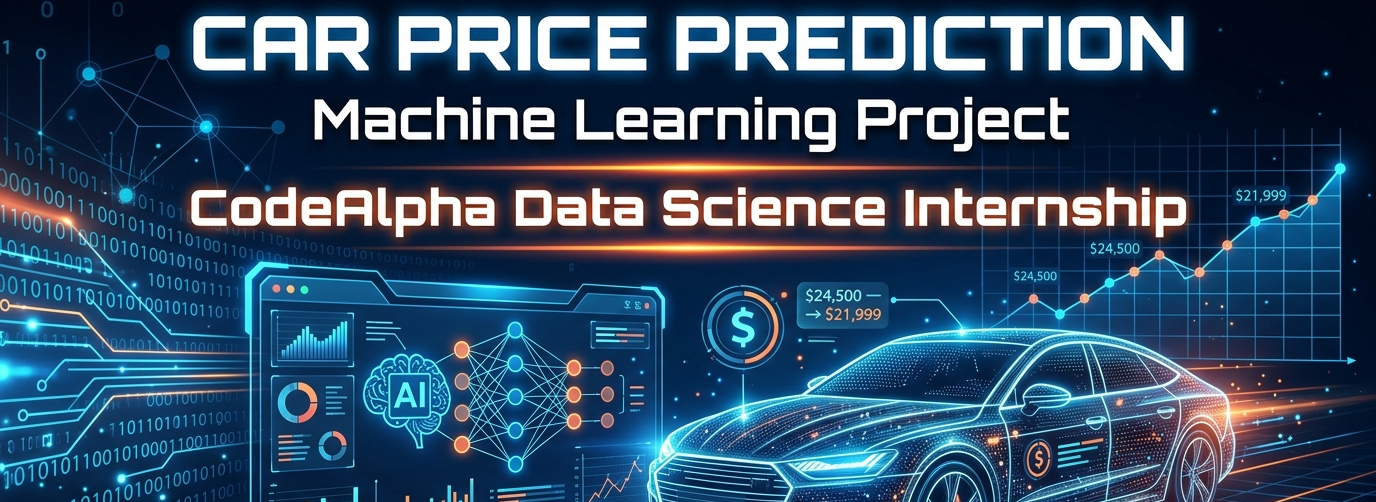
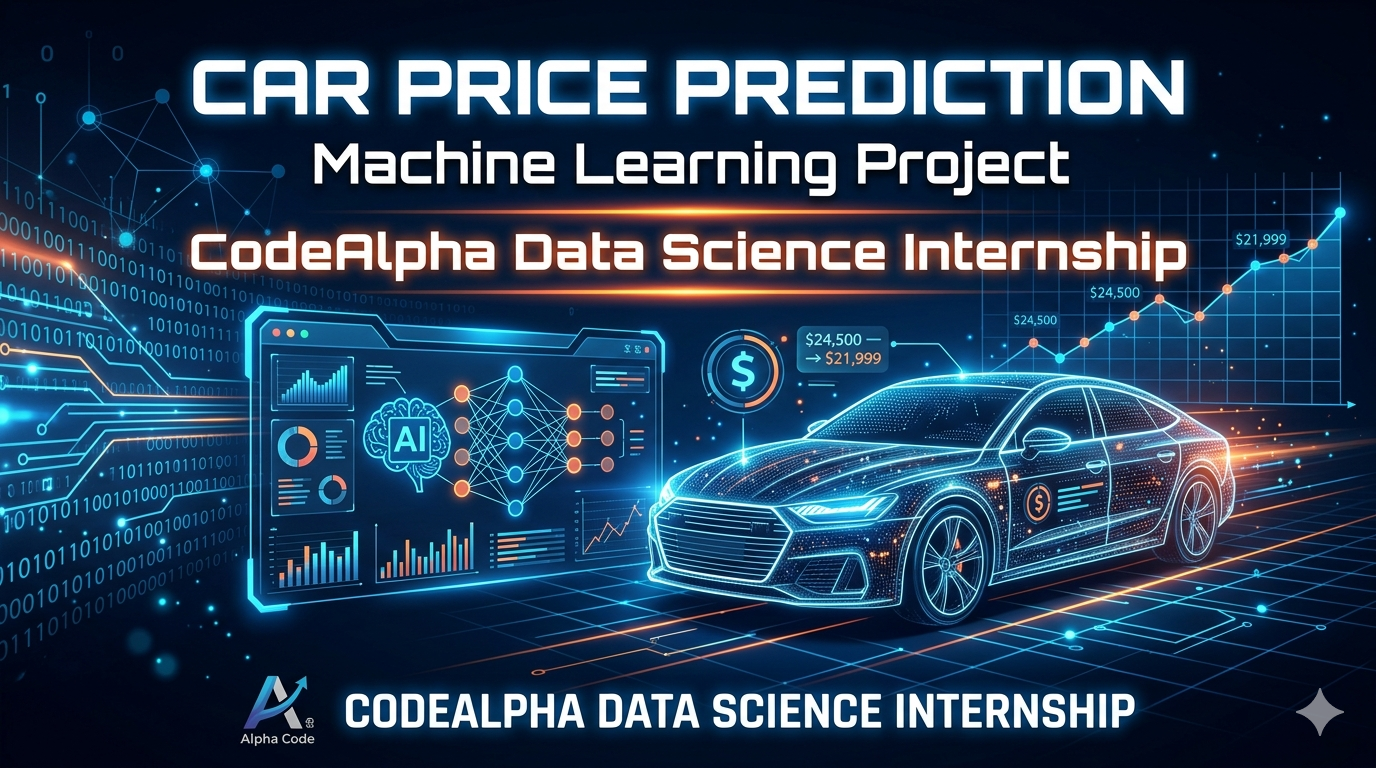

# Car Price Prediction using Machine Learning

## Problem Statement
Predict the selling price of used cars based on vehicle attributes.

## 📚 Importing Required Libraries

The following Python libraries are imported for data manipulation, visualization, preprocessing, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 📂 Loading the Dataset

The dataset contains information about used cars including their present market price, fuel type, transmission type, ownership details, and selling price.

In [2]:
df=pd.read_csv('/kaggle/input/datasets/vijayaadithyanvg/car-price-predictionused-cars/car data.csv')

## 🔍 Data Exploration

Before building machine learning models, it is important to understand the dataset structure, data types, missing values, duplicates, and statistical properties.

In [3]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 🧹 Data Cleaning

Data cleaning involves identifying and handling missing values, removing duplicate records, and ensuring data quality before further analysis.

In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [12]:
df['Selling_type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [13]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [14]:
df['Car_Name'].nunique()

98

In [15]:
df['Car_Age']=2026-df['Year']

In [16]:
df[['Year','Car_Age']].head(5)

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [17]:
df.drop('Year',axis=1,inplace=True)

In [18]:
df.tail()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
296,city,9.50,11.6,33988,Diesel,Dealer,Manual,0,10
297,brio,4.00,5.9,60000,Petrol,Dealer,Manual,0,11
298,city,3.35,11.0,87934,Petrol,Dealer,Manual,0,17
299,city,11.50,12.5,9000,Diesel,Dealer,Manual,0,9
300,brio,5.30,5.9,5464,Petrol,Dealer,Manual,0,10


# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps uncover patterns, relationships, and trends within the dataset through visualizations.

### Distribution of Selling Price

This visualization helps understand how selling prices are distributed and whether the data is skewed or contains outliers.

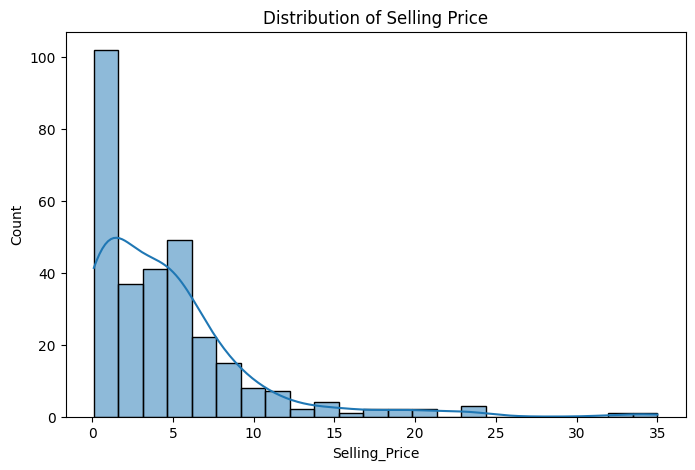

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

### Car Age vs Selling Price

This scatter plot illustrates how the age of a vehicle affects its selling price.

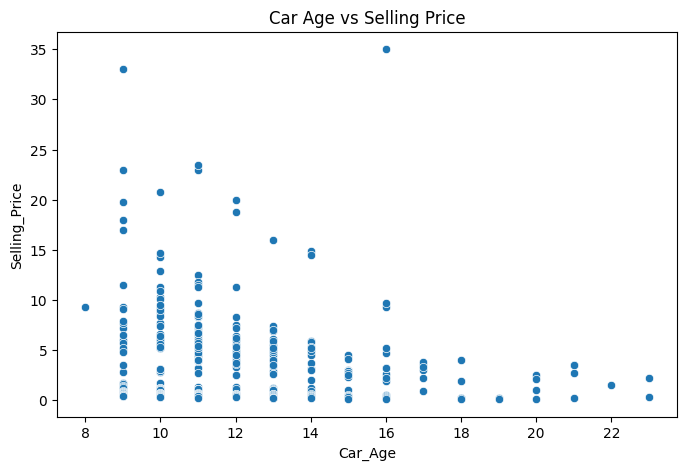

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)
plt.title("Car Age vs Selling Price")
plt.show()

### Fuel Type Analysis

This plot compares selling prices across different fuel types to identify pricing trends.

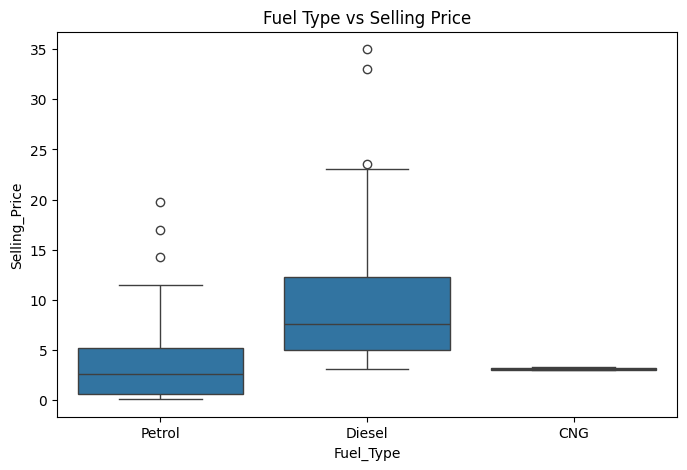

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title("Fuel Type vs Selling Price")
plt.show()

### Transmission Analysis

This visualization examines whether manual or automatic transmission influences vehicle resale value.

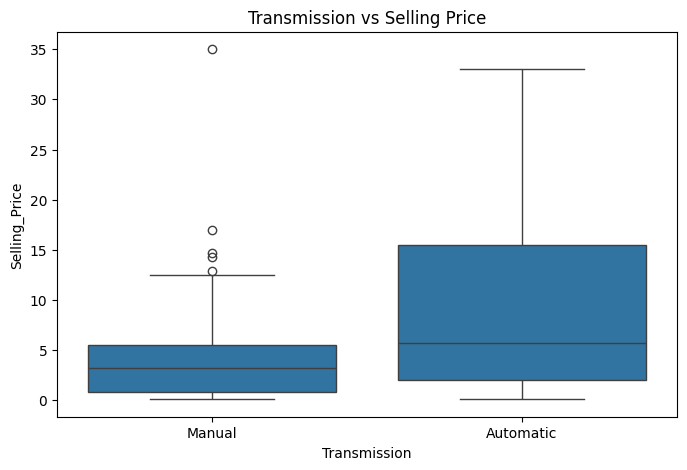

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Transmission', y='Selling_Price', data=df)
plt.title("Transmission vs Selling Price")
plt.show()

### Seller Type Analysis

This analysis compares prices between dealer-listed vehicles and individually sold vehicles.

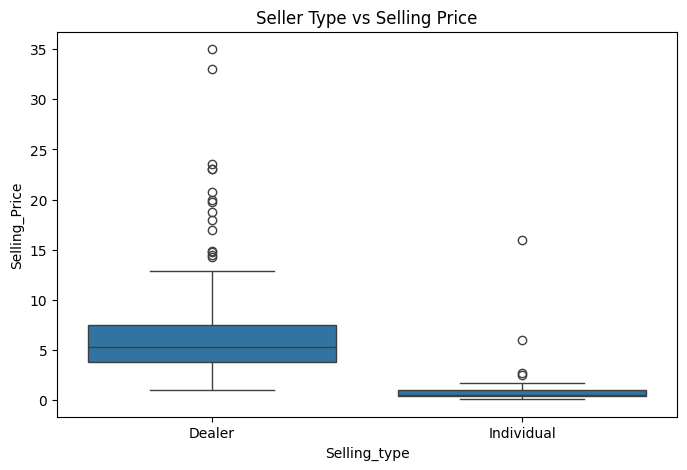

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Selling_type', y='Selling_Price', data=df)
plt.title("Seller Type vs Selling Price")
plt.show()

### Driven Kilometers vs Selling Price

This scatter plot helps determine how vehicle usage impacts resale value.

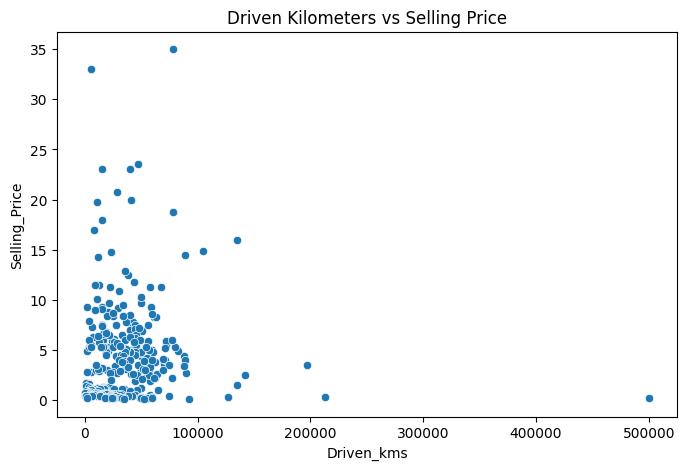

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Driven_kms', y='Selling_Price', data=df)
plt.title("Driven Kilometers vs Selling Price")
plt.show()

### Correlation Analysis

The correlation heatmap identifies relationships among numerical features and highlights the factors most strongly associated with selling price.

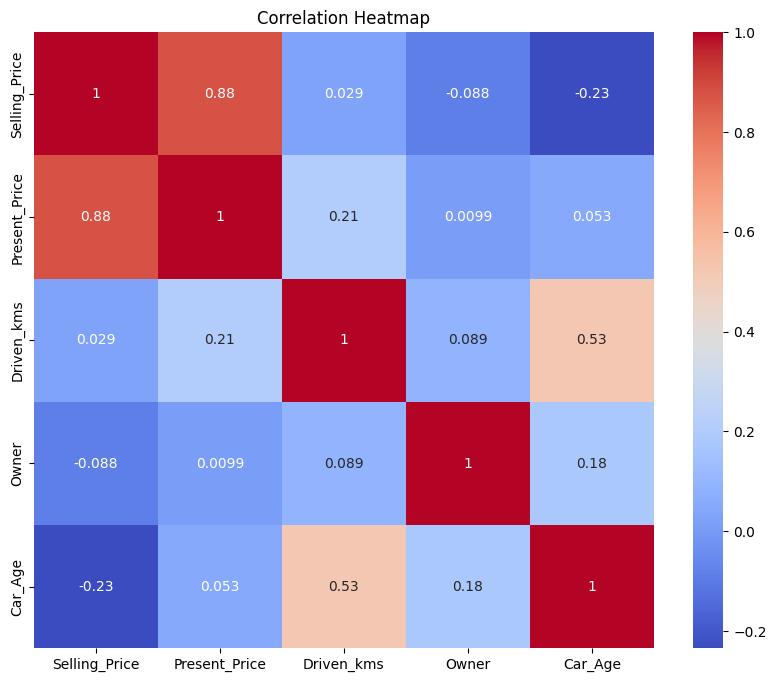

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [26]:
df.columns

Index(['Car_Name', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='object')

In [27]:
df.shape

(299, 9)

In [28]:
df.columns.tolist()

['Car_Name',
 'Selling_Price',
 'Present_Price',
 'Driven_kms',
 'Fuel_Type',
 'Selling_type',
 'Transmission',
 'Owner',
 'Car_Age']

In [29]:
df.tail()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
296,city,9.50,11.6,33988,Diesel,Dealer,Manual,0,10
297,brio,4.00,5.9,60000,Petrol,Dealer,Manual,0,11
298,city,3.35,11.0,87934,Petrol,Dealer,Manual,0,17
299,city,11.50,12.5,9000,Diesel,Dealer,Manual,0,9
300,brio,5.30,5.9,5464,Petrol,Dealer,Manual,0,10


## 🔄 Data Preprocessing and Encoding

Machine learning models require numerical input. Categorical features are converted into numerical format using one-hot encoding.

In [30]:
df = pd.get_dummies(df, drop_first=True)

In [31]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Car_Name_Activa 3g', 'Car_Name_Activa 4g', 'Car_Name_Bajaj  ct 100',
       'Car_Name_Bajaj Avenger 150', 'Car_Name_Bajaj Avenger 150 street',
       ...
       'Car_Name_swift', 'Car_Name_sx4', 'Car_Name_verna',
       'Car_Name_vitara brezza', 'Car_Name_wagon r', 'Car_Name_xcent',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object', length=106)

In [32]:
car_cols=[col for col in df.columns if col.startswith('Car_Name_')]
df.drop(columns=car_cols, inplace=True)

In [33]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')

## 🎯 Feature Selection

The target variable is selected as **Selling_Price**, while all remaining attributes are used as input features for model training.

In [34]:
X=df.drop('Selling_Price',axis=1)
y=df['Selling_Price']

## ✂️ Train-Test Split

The dataset is divided into training and testing sets. The training data is used to build the model, while the testing data evaluates its performance on unseen data.

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(239, 8)
(60, 8)
(239,)
(60,)


# 🤖 Model Training

### Gradient Boosting Regressor

Gradient Boosting builds models sequentially, correcting previous errors and improving overall predictive performance.

In [37]:
from sklearn.ensemble import GradientBoostingRegressor
gradient = GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,max_depth=4,random_state=42)

gradient.fit(X_train, y_train)

pred_grade = gradient.predict(X_test)



In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np

print("R2 score:",r2_score(y_test, pred_grade))
print("MAE:",mean_absolute_error(y_test, pred_grade))
print("RMSE:",np.sqrt(mean_squared_error(y_test, pred_grade)))

R2 score: 0.8246689024245173
MAE: 1.0291358900247265
RMSE: 2.125759712084822


In [39]:
new_car = [[8.5,35000,0,5,0,1,1,1]]

# 🔮 Sample Price Prediction

The trained model can estimate the selling price of a car based on user-provided vehicle characteristics.

In [40]:
predicted_price = gradient.predict(new_car)
print(f"Predicted Selling Price: ₹ {predicted_price[0]:.2f} Lakhs")

Predicted Selling Price: ₹ 6.37 Lakhs


# ✅ Conclusion

This project successfully developed a machine learning solution for predicting used car prices. After data cleaning, feature engineering, exploratory data analysis, and model training, the Gradient Boosting Regressor achieved the best performance with an R² score of 0.824. The results demonstrate the effectiveness of machine learning in estimating vehicle resale values and supporting data-driven pricing decisions.